# Ordinary Differential Equation Solvers

An ordinary differential equation, or ODE, describes how a quantity changes with respect to one variable, usually time.

In many scientific problems, we know the rate of change of a system, but we do not directly know the full solution. Numerical ODE solvers help us approximate the solution step by step.

In this notebook, we compare two numerical methods:

1. Euler Method
2. Fourth-Order Runge-Kutta Method, also called RK4

We solve the test problem:

\[
\frac{dy}{dt} = -2y
\]

with the initial condition:

\[
y(0) = 1
\]

The exact solution is:

\[
y(t) = e^{-2t}
\]

Because the exact solution is known, we can compare the numerical results with the true solution and calculate errors.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Problem Definition

We solve the initial value problem:

\[
\frac{dy}{dt} = -2y
\]

This equation describes exponential decay.

Examples of exponential decay appear in:

- radioactive decay
- chemical reaction kinetics
- cooling processes
- population decay
- damping in physical systems

The initial value is:

\[
y(0) = 1
\]

We solve the equation from:

\[
t = 0
\]

to:

\[
t = 5
\]

In [20]:
def dydt(t, y):
    return -2 * y

def exact_solution(t):
    return np.exp(-2 * t)

# Time interval
t0 = 0
t_end = 5

# Initial condition
y0 = 1

# Step size
h = 0.1

## 2. Euler Method

The Euler method is one of the simplest numerical methods for solving ODEs.

It estimates the next value using the current value and the current slope.

The method is simple and fast, but it can be inaccurate if the step size is too large.

In [21]:
def euler_method(dydt, t0, y0, t_end, h):
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        t_current = t_values[i - 1]
        y_current = y_values[i - 1]
        
        y_values[i] = y_current + h * dydt(t_current, y_current)
    
    return t_values, y_values


t_euler, y_euler = euler_method(dydt, t0, y0, t_end, h)

## 3. Fourth-Order Runge-Kutta Method

The fourth-order Runge-Kutta method, usually called RK4, is a more accurate ODE solver.

Instead of using only one slope per step, RK4 estimates several slopes inside each time interval and combines them.

This makes RK4 much more accurate than Euler's method for the same step size.

In [22]:
def rk4_method(dydt, t0, y0, t_end, h):
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        t_current = t_values[i - 1]
        y_current = y_values[i - 1]
        
        k1 = dydt(t_current, y_current)
        k2 = dydt(t_current + h/2, y_current + h*k1/2)
        k3 = dydt(t_current + h/2, y_current + h*k2/2)
        k4 = dydt(t_current + h, y_current + h*k3)
        
        y_values[i] = y_current + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    
    return t_values, y_values


t_rk4, y_rk4 = rk4_method(dydt, t0, y0, t_end, h)

## 4. Comparing Numerical and Exact Solutions

Now we compare Euler and RK4 with the exact solution.

The exact solution is:

\[
y(t) = e^{-2t}
\]

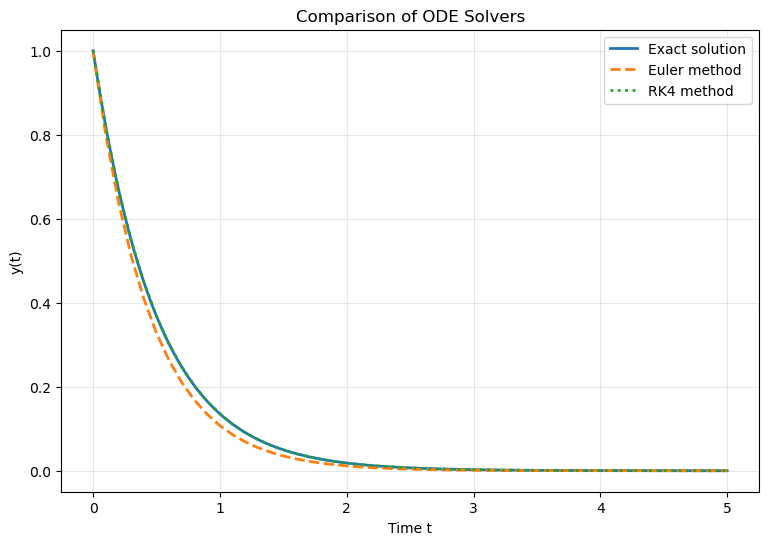

In [24]:
t_exact = np.linspace(t0, t_end, 500)
y_exact = exact_solution(t_exact)

plt.figure(figsize=(9, 6))

plt.plot(t_exact, y_exact, label="Exact solution", linewidth=2)
plt.plot(t_euler, y_euler, "--", label="Euler method", linewidth=2)
plt.plot(t_rk4, y_rk4, ":", label="RK4 method", linewidth=2)

plt.xlabel("Time t")
plt.ylabel("y(t)")
plt.title("Comparison of ODE Solvers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Numerical Results Table

The table below compares the approximate values from Euler and RK4 with the exact solution at selected time points.

In [25]:
y_exact_at_steps = exact_solution(t_euler)

results_table = pd.DataFrame({
    "t": t_euler,
    "Exact solution": y_exact_at_steps,
    "Euler method": y_euler,
    "RK4 method": y_rk4,
    "Euler absolute error": np.abs(y_exact_at_steps - y_euler),
    "RK4 absolute error": np.abs(y_exact_at_steps - y_rk4)
})

results_table.head(10)

,t,Exact solution,Euler method,RK4 method,Euler absolute error,RK4 absolute error
0,0.0,1.000000,1.000000,1.000000,0.000000,0.000000
1,0.1,0.818731,0.800000,0.818733,0.018731,0.000003
2,0.2,0.670320,0.640000,0.670324,0.030320,0.000004
3,0.3,0.548812,0.512000,0.548817,0.036812,0.000005
4,0.4,0.449329,0.409600,0.449335,0.039729,0.000006
5,0.5,0.367879,0.327680,0.367885,0.040199,0.000006
6,0.6,0.301194,0.262144,0.301200,0.039050,0.000006
7,0.7,0.246597,0.209715,0.246602,0.036882,0.000005
8,0.8,0.201897,0.167772,0.201902,0.034124,0.000005
9,0.9,0.165299,0.134218,0.165304,0.031081,0.000005


## 6. Error Analysis

To measure accuracy, we calculate the absolute error:

\[
\text{Absolute Error} = |y_{\text{exact}} - y_{\text{numerical}}|
\]

A smaller error means the numerical method is more accurate.

In [26]:
euler_error = np.abs(y_exact_at_steps - y_euler)
rk4_error = np.abs(y_exact_at_steps - y_rk4)

error_summary = pd.DataFrame({
    "Method": ["Euler method", "RK4 method"],
    "Maximum absolute error": [np.max(euler_error), np.max(rk4_error)],
    "Mean absolute error": [np.mean(euler_error), np.mean(rk4_error)],
    "Final-time absolute error": [euler_error[-1], rk4_error[-1]]
})

error_summary

,Method,Maximum absolute error,Mean absolute error,Final-time absolute error
0,Euler method,0.040199,0.010128,3.112745e-05
1,RK4 method,0.000006,0.000002,7.154517e-09


## 7. Error Visualization

The error plot shows how the error changes over time.

Euler's method usually has a larger error because it uses only the slope at the beginning of each time step.

RK4 has a much smaller error because it uses multiple slope estimates within each step.

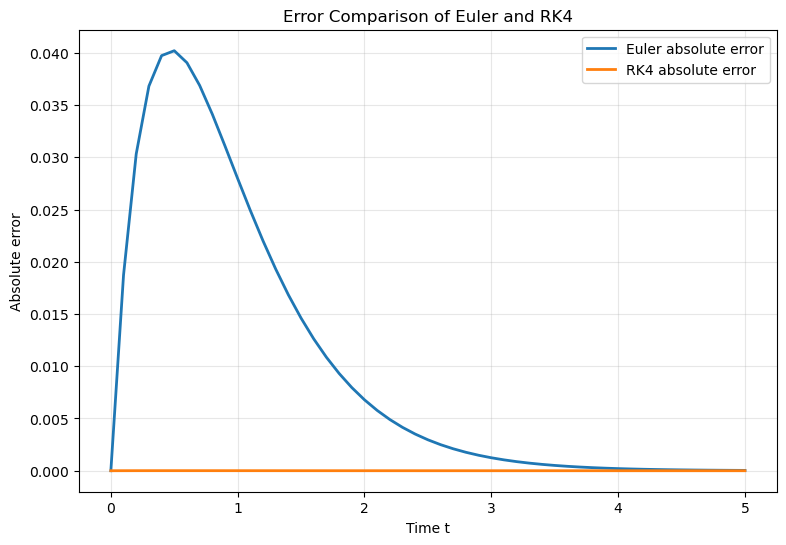

In [28]:
plt.figure(figsize=(9, 6))

plt.plot(t_euler, euler_error, label="Euler absolute error", linewidth=2)
plt.plot(t_rk4, rk4_error, label="RK4 absolute error", linewidth=2)

plt.xlabel("Time t")
plt.ylabel("Absolute error")
plt.title("Error Comparison of Euler and RK4")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Convergence Study

A good numerical method should become more accurate when the step size becomes smaller.

Here, we solve the same ODE using different step sizes:

\[
h = 0.5,\ 0.25,\ 0.1,\ 0.05,\ 0.025
\]

Then we compare the maximum error for Euler and RK4.

In [29]:
step_sizes = [0.5, 0.25, 0.1, 0.05, 0.025]

euler_max_errors = []
rk4_max_errors = []

for step in step_sizes:
    t_e, y_e = euler_method(dydt, t0, y0, t_end, step)
    t_r, y_r = rk4_method(dydt, t0, y0, t_end, step)
    
    exact_e = exact_solution(t_e)
    exact_r = exact_solution(t_r)
    
    euler_max_errors.append(np.max(np.abs(exact_e - y_e)))
    rk4_max_errors.append(np.max(np.abs(exact_r - y_r)))

convergence_table = pd.DataFrame({
    "Step size h": step_sizes,
    "Euler max error": euler_max_errors,
    "RK4 max error": rk4_max_errors
})

convergence_table

,Step size h,Euler max error,RK4 max error
0,0.500,0.367879,7.120559e-03
1,0.250,0.117879,2.914030e-04
2,0.100,0.040199,5.796954e-06
3,0.050,0.019201,3.332411e-07
4,0.025,0.009394,1.997610e-08


## 9. Convergence Plot

This plot shows how the maximum error changes as the step size decreases.

A smaller step size usually gives a smaller error.

RK4 should converge much faster than Euler's method.

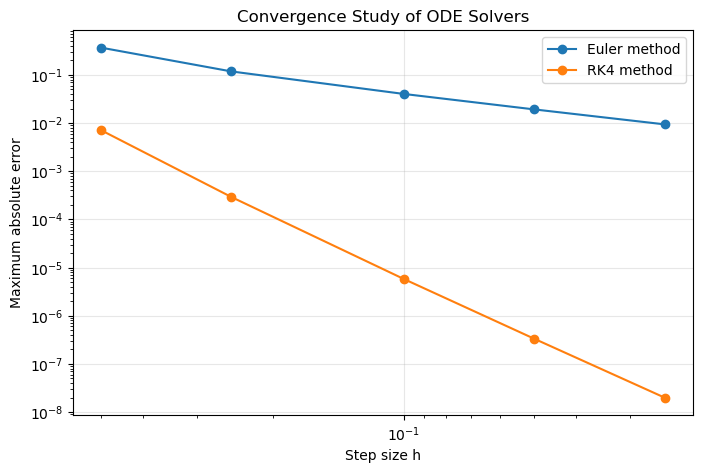

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(step_sizes, euler_max_errors, marker="o", label="Euler method")
plt.plot(step_sizes, rk4_max_errors, marker="o", label="RK4 method")

plt.xlabel("Step size h")
plt.ylabel("Maximum absolute error")
plt.title("Convergence Study of ODE Solvers")
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Discussion

From the results, we observe:

1. Euler's method can solve the ODE, but it has a larger error.
2. RK4 gives a much more accurate solution for the same step size.
3. Decreasing the step size improves the accuracy of both methods.
4. RK4 converges faster than Euler's method.
5. Euler's method is useful for understanding the basic idea of numerical ODE solving, while RK4 is more practical for accurate calculations.

The main trade-off is:

- Euler method is simpler and cheaper per step.
- RK4 is more accurate but requires more function evaluations per step.

For this problem, RK4 is clearly the better method.

## 11. Conclusion

In this notebook, we solved an ordinary differential equation using two numerical methods:

- Euler method
- Fourth-order Runge-Kutta method

We compared both methods with the exact solution and studied their errors.

The results show that RK4 is much more accurate than Euler's method for the same step size.

This notebook demonstrates the basic workflow of solving an ODE numerically:

1. Define the differential equation
2. Set the initial condition
3. Choose a step size
4. Apply a numerical solver
5. Compare with the exact solution
6. Analyze the error
7. Study convergence